##Configuracion##

In [1]:
import numpy as np
import matplotlib.pyplot as plt


NUM_PUNTOS = 5          # puntos intermedios entre inicio y fin
POBLACION = 40
GENERACIONES = 80
PROB_MUTACION = 0.20
t = np.linspace(0,2*np.pi,200)

trayectoria = np.column_stack((
    0.06*np.cos(t),
    0.06*np.sin(t),
    -0.30-0.10*t/(2*np.pi)
))

In [2]:

def distancia_punto_segmento(P,A,B):

    AB = B-A
    AP = P-A

    den = np.dot(AB,AB)

    if den < 1e-12:
        return np.linalg.norm(P-A)

    u = np.clip(np.dot(AP,AB)/den,0,1)

    Q = A + u*AB

    return np.linalg.norm(P-Q)

# RMSE

def calcular_rmse(vertices, trayectoria):

    errores=[]

    for P in trayectoria:

        mejor=np.inf

        for i in range(len(vertices)-1):

            d=distancia_punto_segmento(
                P,
                vertices[i],
                vertices[i+1]
            )

            if d<mejor:
                mejor=d

        errores.append(mejor)

    return np.sqrt(np.mean(np.square(errores)))

# INDIVIDUO

def crear_individuo():

    idx=np.sort(
        np.random.choice(
            np.arange(1,len(trayectoria)-1),
            NUM_PUNTOS,
            replace=False
        )
    )

    return idx

# CONVERTIR INDICES A POLIGONAL

def individuo_a_vertices(ind):

    return np.vstack((
        trayectoria[0],
        trayectoria[ind],
        trayectoria[-1]
    ))

# FITNESS

def fitness(ind):

    v=individuo_a_vertices(ind)

    rmse=calcular_rmse(v,trayectoria)

    return rmse

# TORNEO

def torneo(poblacion):

    candidatos=np.random.choice(len(poblacion),3)

    mejor=min(candidatos,key=lambda i:fitness(poblacion[i]))

    return poblacion[mejor].copy()

# CRUZA

def cruza(a,b):

    hijo=np.concatenate((a[:NUM_PUNTOS//2],
                         b[NUM_PUNTOS//2:]))

    hijo=np.unique(hijo)

    while len(hijo)<NUM_PUNTOS:

        r=np.random.randint(1,len(trayectoria)-1)

        hijo=np.unique(np.append(hijo,r))

    hijo=np.sort(hijo)

    if len(hijo)>NUM_PUNTOS:
        hijo=hijo[:NUM_PUNTOS]

    return hijo

# MUTACION

def mutacion(ind):

    if np.random.rand()>PROB_MUTACION:
        return ind

    pos=np.random.randint(NUM_PUNTOS)

    nuevo=ind.copy()

    nuevo[pos]+=np.random.randint(-5,6)

    nuevo[pos]=np.clip(
        nuevo[pos],
        1,
        len(trayectoria)-2
    )

    nuevo=np.unique(nuevo)

    while len(nuevo)<NUM_PUNTOS:

        r=np.random.randint(1,len(trayectoria)-1)

        nuevo=np.unique(np.append(nuevo,r))

    nuevo=np.sort(nuevo)

    if len(nuevo)>NUM_PUNTOS:
        nuevo=nuevo[:NUM_PUNTOS]

    return nuevo


In [3]:

# POBLACION INICIAL
poblacion=[crear_individuo() for _ in range(POBLACION)]

historial=[]

# algoritmo
for g in range(GENERACIONES):

    poblacion=sorted(
        poblacion,
        key=fitness
    )

    historial.append(fitness(poblacion[0]))

    nueva=[poblacion[0].copy(),
           poblacion[1].copy()]

    while len(nueva)<POBLACION:

        p1=torneo(poblacion)

        p2=torneo(poblacion)

        hijo=cruza(p1,p2)

        hijo=mutacion(hijo)

        nueva.append(hijo)

    poblacion=nueva

    if g%10==0:
        print(f"Generacion {g} RMSE={historial[-1]:.6f}")


Generacion 0 RMSE=0.008670
Generacion 10 RMSE=0.006037
Generacion 20 RMSE=0.005865
Generacion 30 RMSE=0.005849
Generacion 40 RMSE=0.005849
Generacion 50 RMSE=0.005849
Generacion 60 RMSE=0.005849
Generacion 70 RMSE=0.005849



Mejor RMSE: 0.005849181412189397


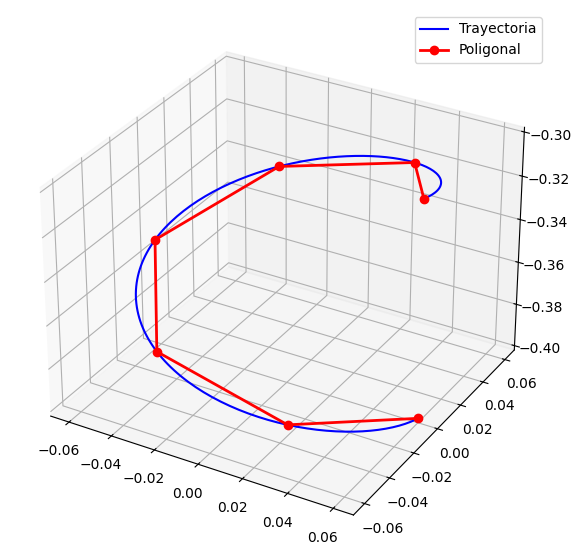

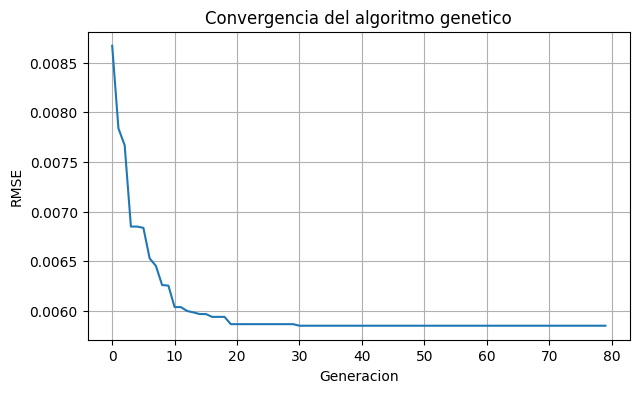

In [4]:
#resultado
mejor=poblacion[0]

vertices=individuo_a_vertices(mejor)

print("\nMejor RMSE:",fitness(mejor))

# GRAFICAS

fig=plt.figure(figsize=(8,7))
ax=fig.add_subplot(111,projection='3d')

ax.plot(
    trayectoria[:,0],
    trayectoria[:,1],
    trayectoria[:,2],
    'b',
    label="Trayectoria"
)

ax.plot(
    vertices[:,0],
    vertices[:,1],
    vertices[:,2],
    'ro-',
    linewidth=2,
    label="Poligonal"
)

ax.legend()

plt.show()

plt.figure(figsize=(7,4))
plt.plot(historial)
plt.grid(True)
plt.xlabel("Generacion")
plt.ylabel("RMSE")
plt.title("Convergencia del algoritmo genetico")
plt.show()

In [5]:
import pandas as pd

# Guardar  original
pd.DataFrame(
    trayectoria,
    columns=["X", "Y", "Z"]
).to_csv("trayectoria_original_2.csv", index=False)

# Guardar optimizada
pd.DataFrame(
    vertices,
    columns=["X", "Y", "Z"]
).to_csv("trayectoria_optimizada_2.csv", index=False)
